In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.cluster import KMeans

# Data Collection and Analysis

In [2]:
customer_data=pd.read_csv('Mall_Customers.csv')

In [3]:
customer_data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
customer_data.shape

(200, 5)

In [5]:
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
customer_data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [7]:
customer_data.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

### Choosing Annual Income and Spending Score Column

In [8]:
X=customer_data.iloc[:,[3,4]].values

# Choosing Number of Clusters 
### WCSS ----> Within Clusters Sum of Squares

In [11]:
#finding wcss valus for differenct number of clusters 
wcss=[]
for i in range(1,11): 
    kmeans=KMeans(n_clusters=i,init='k-means++', random_state=42)
    kmeans.fit(X) 
    wcss.append(kmeans.inertia_)

# Elbow Graph

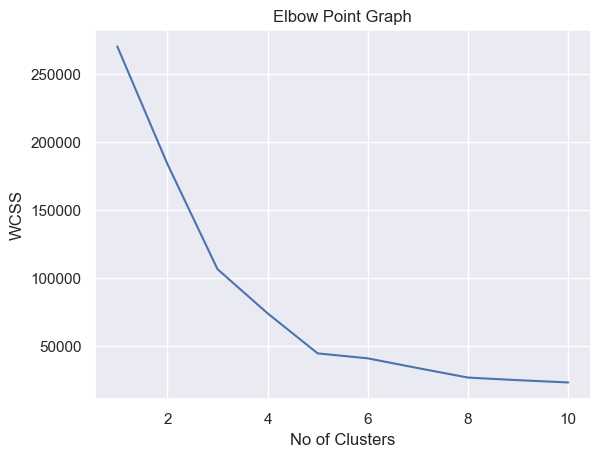

In [14]:
sns.set()
plt.plot(range(1,11), wcss) 
plt.title("Elbow Point Graph")
plt.xlabel('No of Clusters')
plt.ylabel('WCSS')
plt.show()

#### Optimum Number of Clusters is 5

#  Training K-Means Clustering Model

In [19]:
kmeans=KMeans(n_clusters=5, init='k-means++', random_state=42)

In [20]:
Y=kmeans.fit_predict(X) 
print(Y)

[4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4
 2 4 2 4 2 4 0 4 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 3 1 0 1 3 1 3 1 0 1 3 1 3 1 3 1 3 1 0 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]


### Y contains the cluster label (0-4) assigned to each customer

# Visualizing All Clusters

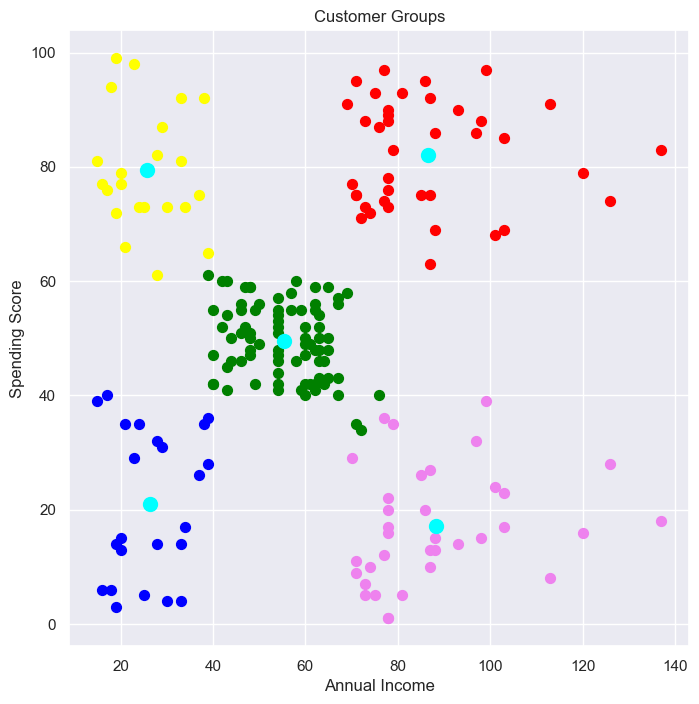

In [24]:
plt.figure(figsize=(8,8))
plt.scatter(X[Y==0,0],X[Y==0,1], s=50,c='green', label='Cluster 1') # first X represent 0 index of x and cluster value [cluster,index]:[0,0]
plt.scatter(X[Y==1,0],X[Y==1,1], s=50,c='red', label='Cluster 2')
plt.scatter(X[Y==2,0],X[Y==2,1], s=50,c='yellow', label='Cluster 3') 
plt.scatter(X[Y==3,0],X[Y==3,1], s=50,c='violet', label='Cluster 4')  
plt.scatter(X[Y==4,0],X[Y==4,1], s=50,c='blue', label='Cluster 5') 

# plot the Centroid 
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s=100, c='cyan', label='Centroid') # 0 represent x-axis value of centroid and 1 represent y-axis
plt.title("Customer Groups")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()

## Cluster Interpretation
- Cluster 1 (Green) — Low income, Low spending → careful customers
- Cluster 2 (Red) — High income, High spending → target customers (most valuable)
- Cluster 3 (Yellow) — Low income, High spending → impulsive buyers
- Cluster 4 (Violet) — High income, Low spending → potential customers (need targeted marketing)
- Cluster 5 (Blue) — Medium income, Medium spending → standard customers